<a href="https://colab.research.google.com/github/BiprajitPaul/Agentic-AI/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. We have to initialise the K value
    k>0 ...... infinity
    k=1,2,3,4,5,...... means 1 neighbours 2 neighbours => hyperparameter
2. Lets say we get k =5 which gives highest accuracy
    -> Now we find the k Nearest neighbour for the test data.
    

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, # 1000 observation
    n_features=5, # Total 5 features
    n_classes=2, # Binary target/label
    n_redundant=1,
    random_state=42,
)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [ ]:
classifier = KNeighborsClassifier(n_neighbors=10 , algorithm='auto' , p=1)
classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10, p=1)

In [ ]:
y_pred = classifier.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

[[155  13]
 [ 28 134]]
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       168
           1       0.91      0.83      0.87       162

    accuracy                           0.88       330
   macro avg       0.88      0.87      0.88       330
weighted avg       0.88      0.88      0.88       330

0.8757575757575757


# Task
## Perform GridSerachCv
## for i in k=1,2,3,4,5,6,7,8,9,10

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'n_neighbors': list(range(1, 11)),
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

knn_classifier = KNeighborsClassifier()
grid_search = GridSearchCV(knn_classifier, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'p': [1, 2]},
             scoring='accuracy')

### Best parameters and score from GridSearchCV

In [ ]:
print("Best parameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

Best parameters:  {'algorithm': 'auto', 'n_neighbors': 5, 'p': 1}
Best score:  0.9014925373134328


### Evaluate the model with the best parameters on the test set

In [ ]:
best_knn_classifier = grid_search.best_estimator_
y_pred_best = best_knn_classifier.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))
print("\nAccuracy Score: ", accuracy_score(y_test, y_pred_best))

Confusion Matrix:
 [[156  12]
 [ 26 136]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.89       168
           1       0.92      0.84      0.88       162

    accuracy                           0.88       330
   macro avg       0.89      0.88      0.88       330
weighted avg       0.89      0.88      0.88       330


Accuracy Score:  0.8848484848484849


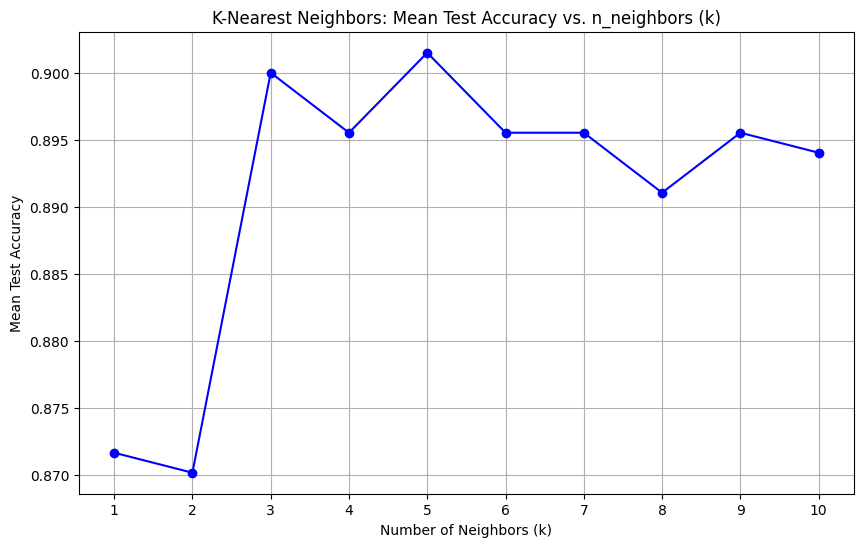

In [ ]:
import matplotlib.pyplot as plt

# Extract results from GridSearchCV
results = grid_search.cv_results_

# Get n_neighbors values and their corresponding mean test scores
k_values = [param['n_neighbors'] for param in results['params'] if param['algorithm'] == grid_search.best_params_['algorithm'] and param['p'] == grid_search.best_params_['p']]
mean_test_scores = [score for i, score in enumerate(results['mean_test_score']) if results['params'][i]['algorithm'] == grid_search.best_params_['algorithm'] and results['params'][i]['p'] == grid_search.best_params_['p']]

# Sort by k_values to ensure the plot is ordered correctly
sorted_results = sorted(zip(k_values, mean_test_scores))
sorted_k_values = [k for k, score in sorted_results]
sorted_mean_test_scores = [score for k, score in sorted_results]

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(sorted_k_values, sorted_mean_test_scores, marker='o', linestyle='-', color='b')
plt.title('K-Nearest Neighbors: Mean Test Accuracy vs. n_neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean Test Accuracy')
plt.xticks(sorted_k_values) # Ensure all k values are shown on x-axis
plt.grid(True)
plt.show()